# FineBio — Multi-View Least-Squares 3D Localisation (v2)
Extracts frames directly from videos on the fly, loads all 5 TPV cameras into
the shared board coordinate frame, and solves for per-object 3D positions via
least-squares ray intersection across all views that see each object.

## 1. Install dependencies

In [1]:
!pip install opencv-python numpy matplotlib tqdm ultralytics -q

## 2. Config

In [ ]:
from pathlib import Path
import numpy as np

FINEBIO_ROOT = Path("/home/nyan/FineBio")
CAL_ROOT     = FINEBIO_ROOT / "14 misc/finebio_camera_poses/finebio_camera_poses"
YOLO_WEIGHTS = Path("./runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt")

# Trial to process — change to any valid trial ID
TRIAL_ID     = "P01_01_01"

# T1-T5 suffix -> board extrinsic camera ID (from README + directory listing)
# T1=1, T2=2, T3=3, T4=4, T5=6  (no cam 5 in the dataset)
T_TO_CAM_ID  = {"T1": 1, "T2": 2, "T3": 3, "T4": 4, "T5": 6}

# Recording date for this trial — used to find extrinsics folder
# Check third_person_camera_poses/ for available dates
TRIAL_DATE   = "221207"

# Which folder contains the TPV videos for this trial
# (train/valid/test — check which split your trial belongs to)
TPV_VIDEO_DIR = FINEBIO_ROOT / "05 finebio_videos_tpv_train" / "finebio_videos"
FPV_VIDEO_DIR = FINEBIO_ROOT / "09 finebio_videos_fpv_train" / "finebio_videos"

CONF_THRESH  = 0.3
HAND_CLASSES = ["left_hand", "right_hand", "hand"]

# Frame extraction: process every Nth frame (30fps video → FRAME_STEP=3 gives ~10fps)
FRAME_STEP   = 3

print(f"Trial      : {TRIAL_ID}")
print(f"TPV videos : {TPV_VIDEO_DIR}")
print(f"FPV video  : {FPV_VIDEO_DIR / (TRIAL_ID + '.mp4')}")

# Verify video files exist
for suffix, cam_id in T_TO_CAM_ID.items():
    p = TPV_VIDEO_DIR / f"{TRIAL_ID}_{suffix}.mp4"
    status = "OK" if p.exists() else "MISSING"
    print(f"  {p.name}: {status}")
fp_path = FPV_VIDEO_DIR / f"{TRIAL_ID}.mp4"
print(f"  {fp_path.name}: {'OK' if fp_path.exists() else 'MISSING'}")

Trial      : P01_01_01
TPV videos : /home/nyan/FineBio/05 finebio_videos_tpv_train/finebio_videos
FPV video  : /home/nyan/FineBio/09 finebio_videos_fpv_train/finebio_videos/P01_01_01.mp4
  P01_01_01_T1.mp4: OK
  P01_01_01_T2.mp4: OK
  P01_01_01_T3.mp4: OK
  P01_01_01_T4.mp4: OK
  P01_01_01_T5.mp4: OK
  P01_01_01.mp4: OK


## 3. Frame extractor — reads directly from video files

In [3]:
import cv2
import numpy as np

def get_frame(video_path, frame_idx):
    """
    Extract a single frame from a video file by index.
    Returns the frame as a numpy array (BGR), or None if out of range.
    """
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
    ret, frame = cap.read()
    cap.release()
    return frame if ret else None


def get_video_info(video_path):
    """Returns (total_frames, fps, width, height) for a video file."""
    cap = cv2.VideoCapture(str(video_path))
    total  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps    = cap.get(cv2.CAP_PROP_FPS)
    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return total, fps, width, height


def build_video_map(trial_id, tpv_dir, fpv_dir, t_to_cam_id):
    """
    Returns {cam_id: video_path} for all cameras in a trial.
    cam_id is the board extrinsic integer (1,2,3,4,6) for TPV, 'fp' for FPV.
    """
    video_map = {}
    for suffix, cam_id in t_to_cam_id.items():
        p = tpv_dir / f"{trial_id}_{suffix}.mp4"
        if p.exists():
            video_map[cam_id] = p
        else:
            print(f"  Warning: {p.name} not found")
    fp = fpv_dir / f"{trial_id}.mp4"
    if fp.exists():
        video_map["fp"] = fp
    else:
        print(f"  Warning: {fp.name} not found")
    return video_map


video_map = build_video_map(TRIAL_ID, TPV_VIDEO_DIR, FPV_VIDEO_DIR, T_TO_CAM_ID)

print("Video map:")
for cam_id, path in video_map.items():
    total, fps, w, h = get_video_info(path)
    print(f"  Cam {cam_id}: {path.name}  {w}x{h}  {fps:.1f}fps  {total} frames")

Video map:
  Cam 1: P01_01_01_T1.mp4  1920x1080  30.0fps  4339 frames
  Cam 2: P01_01_01_T2.mp4  1920x1080  30.0fps  4339 frames
  Cam 3: P01_01_01_T3.mp4  1920x1080  30.0fps  4339 frames
  Cam 4: P01_01_01_T4.mp4  1920x1080  30.0fps  4339 frames
  Cam 6: P01_01_01_T5.mp4  1920x1080  30.0fps  4339 frames
  Cam fp: P01_01_01.mp4  1920x1440  30.0fps  4339 frames


## 4. Camera calibration loader
Loads all cameras into the shared board coordinate frame.
Rescales K when video resolution differs from calibration resolution.

In [ ]:
def rescale_K(K, original_width, actual_width):
    """Scale intrinsic matrix when using resized frames."""
    if original_width == actual_width:
        return K.copy()
    scale    = actual_width / original_width
    K_scaled = K.copy().astype(np.float64)
    K_scaled[0, :] *= scale
    K_scaled[1, :] *= scale
    return K_scaled


def load_intrinsics(npz_path):
    data = np.load(npz_path)
    K    = data["intrinsic_matrix"].astype(np.float64)
    dist = data["distCoeff"].astype(np.float64).flatten()
    assert K.shape == (3, 3), f"Bad K shape: {K.shape}"
    assert dist.size in [4, 5, 8, 12, 14], f"Bad dist size: {dist.size}"
    return K, dist


def load_extrinsics(npz_path):
    data = np.load(npz_path)
    keys = set(data.files)

    # FineBio calibration dumps may store Rodrigues+translation as either
    # ('rvec','tvec') or ('r','t'). Support both.
    if "rvec" in keys:
        rvec = data["rvec"]
    elif "r" in keys:
        rvec = data["r"]
    else:
        raise KeyError(f"Extrinsics missing rvec/r keys. Keys: {list(data.files)} ({npz_path})")

    if "tvec" in keys:
        tvec = data["tvec"]
    elif "t" in keys:
        tvec = data["t"]
    else:
        raise KeyError(f"Extrinsics missing tvec/t keys. Keys: {list(data.files)} ({npz_path})")

    rvec = np.asarray(rvec).flatten()
    tvec = np.asarray(tvec).flatten()

    R, _ = cv2.Rodrigues(rvec.reshape(3, 1))
    t = tvec.reshape(3, 1)
    return R.astype(np.float64), t.astype(np.float64)


def build_projection_matrix(K, R, t):
    return (K @ np.hstack([R, t])).astype(np.float64)


def load_static_cameras(cal_root, trial_date, video_map):
    """
    Load all TPV cameras into shared board frame.
    Rescales K to match actual video resolution.
    Returns {cam_id: {K, dist, R, t, P, pos_world}}
    """
    # Calibration was done at 3840x2160 for TPV
    CAL_WIDTH_TP = 3840

    K_tp, dist_tp = load_intrinsics(
        cal_root / "intrinsic_parameters" / "gopro9_6_linear_4k_169_0.50.npz"
    )

    cameras = {}
    for cam_id, video_path in video_map.items():
        if cam_id == "fp":
            continue
        ext_path = cal_root / "third_person_camera_poses" / trial_date / "extrinsics" / f"{cam_id}_board.npz"
        R, t     = load_extrinsics(ext_path)

        # Get actual video width to rescale K
        _, _, actual_w, _ = get_video_info(video_path)
        K_scaled  = rescale_K(K_tp, CAL_WIDTH_TP, actual_w)
        pos_world = (-R.T @ t).flatten()

        cameras[cam_id] = {
            "K"        : K_scaled,
            "dist"     : dist_tp,
            "R"        : R,
            "t"        : t,
            "P"        : build_projection_matrix(K_scaled, R, t),
            "pos_world": pos_world,
        }
        print(f"  Cam {cam_id}: world_pos=({pos_world[0]:.1f}, {pos_world[1]:.1f}, {pos_world[2]:.1f})  K scaled for {actual_w}px width")

    return cameras


def load_fp_pose(cal_root, trial_id):
    """Load first-person camera pose npz (per-frame poses)."""
    path = cal_root / "first_person_camera_poses" / f"{trial_id}.npz"
    data = np.load(path)
    print(f"FP pose keys: {list(data.files)}")
    return data


def get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx):
    """Resolve fp camera extrinsics at a specific frame index."""
    R = fp_npz["rots"][frame_idx].astype(np.float64)
    t = fp_npz["trans"][frame_idx].astype(np.float64).reshape(3, 1)
    return {
        "K"        : K_fp,
        "dist"     : dist_fp,
        "R"        : R,
        "t"        : t,
        "P"        : build_projection_matrix(K_fp, R, t),
        "pos_world": (-R.T @ t).flatten(),
    }


# Load static cameras
static_cameras = load_static_cameras(CAL_ROOT, TRIAL_DATE, video_map)

# Load FP intrinsics and poses
K_fp_raw, dist_fp = load_intrinsics(
    CAL_ROOT / "intrinsic_parameters" / "gopro9_5_wide_4k_43_0.50.npz"
)
fp_npz = load_fp_pose(CAL_ROOT, TRIAL_ID)

# Rescale FP K to actual video resolution (calibrated at 4000px width)
_, _, fp_actual_w, _ = get_video_info(video_map["fp"])
K_fp = rescale_K(K_fp_raw, original_width=4000, actual_width=fp_actual_w)
print(f"FP K rescaled for {fp_actual_w}px width")

  Cam 1: world_pos=(-67.7, -42.0, -59.0)  K scaled for 1920px width
  Cam 2: world_pos=(92.8, -36.3, -63.3)  K scaled for 1920px width
  Cam 3: world_pos=(-68.5, 27.7, -55.6)  K scaled for 1920px width
  Cam 4: world_pos=(93.4, 33.1, -62.6)  K scaled for 1920px width
  Cam 6: world_pos=(9.6, 8.4, -86.8)  K scaled for 1920px width
FP pose keys: ['rets', 'rots', 'trans']
FP K rescaled for 1920px width


## 5. Visualise camera layout in shared board frame

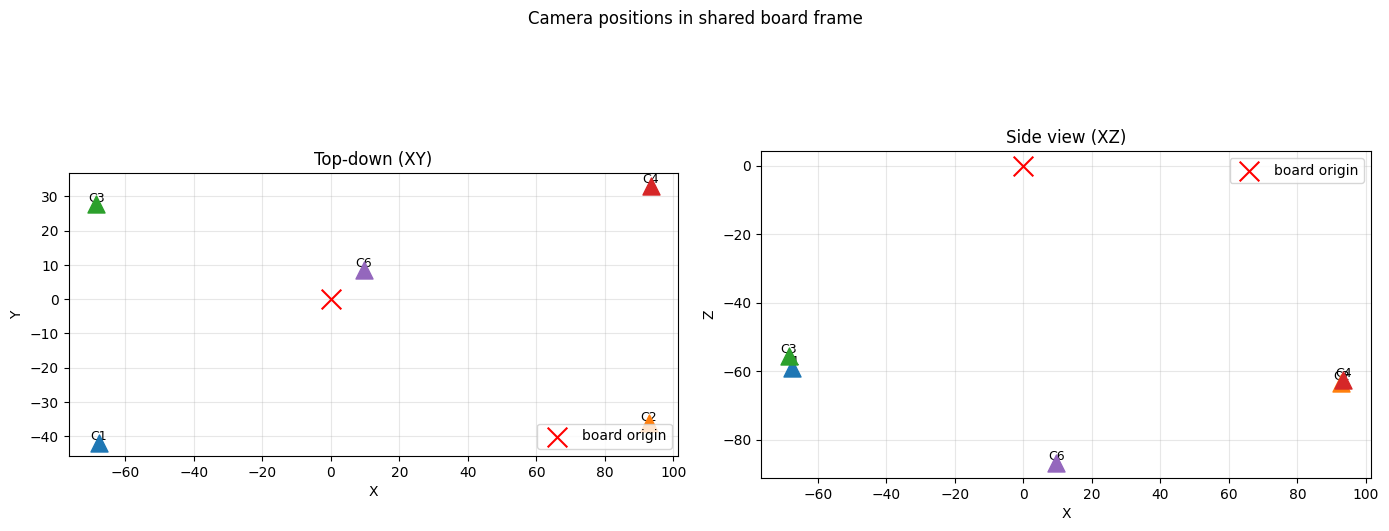

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, (da, db, xl, yl, title) in zip(axes, [
    (0, 1, "X", "Y", "Top-down (XY)"),
    (0, 2, "X", "Z", "Side view (XZ)"),
]):
    for cam_id, cam in static_cameras.items():
        p = cam["pos_world"]
        ax.scatter(p[da], p[db], s=150, marker="^", zorder=4)
        ax.annotate(f"C{cam_id}", (p[da], p[db]), fontsize=9, ha="center", va="bottom")
    ax.scatter(0, 0, s=200, marker="x", color="red", zorder=5, label="board origin")
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title)
    ax.legend(); ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.suptitle("Camera positions in shared board frame", fontsize=12)
plt.tight_layout()
plt.show()

## 6. YOLO26 detector

In [9]:
from ultralytics import YOLO
import tempfile, os

model        = YOLO(str(YOLO_WEIGHTS))
cat_names    = model.names
hand_cls_ids = {k for k, v in cat_names.items() if v.lower() in HAND_CLASSES}
print(f"Loaded YOLO26 — {len(cat_names)} classes, hand ids: {hand_cls_ids}")


def detect_frame_array(frame_bgr, model, conf=CONF_THRESH):
    """
    Run YOLO on a numpy BGR frame (no disk I/O).
    Returns list of detection dicts.
    """
    result = model(frame_bgr, conf=conf, verbose=False)[0]
    dets   = []
    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        cls_id = int(box.cls[0])
        dets.append({
            "cls_id"     : cls_id,
            "cls_name"   : cat_names[cls_id],
            "conf"       : float(box.conf[0]),
            "bbox_xyxy"  : [x1, y1, x2, y2],
            "bbox_center": [(x1 + x2) / 2, (y1 + y2) / 2],
        })
    return dets


def detect_all_views(frame_idx, video_map, model):
    """
    Extract frame_idx from every video and run YOLO.
    Returns {cam_id: [detections]}
    """
    all_dets = {}
    for cam_id, video_path in video_map.items():
        frame = get_frame(video_path, frame_idx)
        if frame is None:
            print(f"  Cam {cam_id}: frame {frame_idx} out of range")
            all_dets[cam_id] = []
            continue
        dets = detect_frame_array(frame, model)
        all_dets[cam_id] = dets
        print(f"  Cam {cam_id}: {len(dets)} detections")
    return all_dets


# Test on frame 100
print("Testing detection on frame 100...")
test_dets = detect_all_views(100, video_map, model)

Loaded YOLO26 — 35 classes, hand ids: {0, 1}
Testing detection on frame 100...
  Cam 1: 11 detections
  Cam 2: 19 detections
  Cam 3: 15 detections
  Cam 4: 20 detections
  Cam 6: 14 detections
  Cam fp: 19 detections


## 7. Least-squares ray intersection

In [10]:
def pixel_to_ray(pt_2d, K, dist, R, t):
    """
    Unproject a 2D pixel to a world-space ray.
    Returns (origin, unit_direction) both in world coordinates.
    """
    pt       = np.array([[pt_2d]], dtype=np.float64)
    pt_u     = cv2.undistortPoints(pt, K, dist, P=K)[0][0]
    ray_cam  = np.linalg.inv(K) @ np.array([pt_u[0], pt_u[1], 1.0])
    ray_world = R.T @ ray_cam
    ray_world = ray_world / np.linalg.norm(ray_world)
    origin    = (-R.T @ t).flatten()
    return origin, ray_world


def least_squares_ray_intersection(rays):
    """
    Find the 3D point minimizing sum of squared distances to N rays.
    rays: list of (origin, direction) tuples.
    Returns (point_3d, mean_ray_distance).
    """
    A = np.zeros((3, 3))
    b = np.zeros(3)
    for origin, direction in rays:
        d = direction.reshape(3, 1)
        o = origin.reshape(3, 1)
        M = np.eye(3) - d @ d.T
        A += M
        b += (M @ o).flatten()
    X, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
    dists = []
    for origin, direction in rays:
        diff    = X - origin
        closest = origin + np.dot(diff, direction) * direction
        dists.append(np.linalg.norm(X - closest))
    return X, float(np.mean(dists))


def localise_all_objects(all_dets, static_cameras, fp_cam, hand_cls_ids):
    """
    For each detected object class, cast rays from all cameras that see it
    and solve for 3D position in board space.
    """
    class_rays     = {}   # cls_name -> [(origin, dir, cam_id, conf)]
    class_best_det = {}   # cls_name -> best detection dict

    for cam_id, dets in all_dets.items():
        cam = fp_cam if cam_id == "fp" else static_cameras.get(cam_id)
        if cam is None:
            continue

        # Best detection per class per camera
        best_per_class = {}
        for det in dets:
            if det["cls_id"] in hand_cls_ids:
                continue
            cls = det["cls_name"]
            if cls not in best_per_class or det["conf"] > best_per_class[cls]["conf"]:
                best_per_class[cls] = det

        for cls, det in best_per_class.items():
            try:
                origin, direction = pixel_to_ray(
                    det["bbox_center"],
                    cam["K"], cam["dist"], cam["R"], cam["t"]
                )
                class_rays.setdefault(cls, []).append((origin, direction, cam_id, det["conf"]))
                if cls not in class_best_det or det["conf"] > class_best_det[cls]["conf"]:
                    class_best_det[cls] = {**det, "cam_id": cam_id}
            except Exception as e:
                print(f"  Ray error {cls} cam {cam_id}: {e}")

    results = {}
    for cls, ray_list in class_rays.items():
        rays         = [(o, d) for o, d, _, _ in ray_list]
        contributing = [c for _, _, c, _ in ray_list]
        if len(rays) == 1:
            results[cls] = {"pos3d": None, "mean_ray_dist": None,
                            "n_views": 1, "contributing_cams": contributing,
                            "best_det": class_best_det[cls]}
        else:
            pos3d, mean_dist = least_squares_ray_intersection(rays)
            results[cls] = {"pos3d": pos3d, "mean_ray_dist": mean_dist,
                            "n_views": len(rays), "contributing_cams": contributing,
                            "best_det": class_best_det[cls]}
    return results


print("Ray intersection functions defined.")

Ray intersection functions defined.


## 8. Test localisation on a single frame

In [11]:
FRAME_IDX = 100

all_dets = detect_all_views(FRAME_IDX, video_map, model)
fp_cam   = get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, FRAME_IDX)
obj_pos  = localise_all_objects(all_dets, static_cameras, fp_cam, hand_cls_ids)

print(f"\nLocalised {len(obj_pos)} objects at frame {FRAME_IDX}:")
print(f"{'Object':<30} {'X':>8} {'Y':>8} {'Z':>8} {'ray_err':>8} {'views':>6}  cams")
print("-" * 85)
for cls, r in sorted(obj_pos.items()):
    if r["pos3d"] is not None:
        X, Y, Z = r["pos3d"]
        print(f"{cls:<30} {X:>8.1f} {Y:>8.1f} {Z:>8.1f} {r['mean_ray_dist']:>8.2f} {r['n_views']:>6}  {r['contributing_cams']}")
    else:
        print(f"{cls:<30} {'N/A':>29} {r['n_views']:>6}  {r['contributing_cams']} (single view)")

  Cam 1: 11 detections
  Cam 2: 19 detections
  Cam 3: 15 detections
  Cam 4: 20 detections
  Cam 6: 14 detections
  Cam fp: 19 detections


ValueError: cannot reshape array of size 1 into shape (3,1)

## 9. Visualise detections + 3D positions side by side

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Left: all camera views with detections
n_cams = len(video_map)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (cam_id, video_path) in zip(axes, video_map.items()):
    frame = get_frame(video_path, FRAME_IDX)
    if frame is None:
        ax.set_title(f"Cam {cam_id} — no frame")
        continue
    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    for det in all_dets.get(cam_id, []):
        x1, y1, x2, y2 = det["bbox_xyxy"]
        is_hand = det["cls_id"] in hand_cls_ids
        color   = "red" if is_hand else "lime"
        rect    = patches.Rectangle((x1, y1), x2-x1, y2-y1,
                                     linewidth=1.5, edgecolor=color, facecolor="none")
        ax.add_patch(rect)
        ax.text(x1, y1-4, det["cls_name"], color=color, fontsize=5, fontweight="bold")
    ax.set_title(f"Cam {cam_id}", fontsize=9)
    ax.axis("off")

# Hide unused subplots
for ax in axes[len(video_map):]:
    ax.axis("off")

plt.suptitle(f"Detections across all views — frame {FRAME_IDX}", fontsize=12)
plt.tight_layout()
plt.show()

# Right: top-down 3D positions
fig, ax = plt.subplots(figsize=(10, 8))
for cam_id, cam in static_cameras.items():
    p = cam["pos_world"]
    ax.scatter(p[0], p[1], s=150, marker="^", color="gray", zorder=4)
    ax.annotate(f"C{cam_id}", (p[0], p[1]), fontsize=8, color="gray")
ax.scatter(0, 0, s=200, marker="x", color="red", zorder=5, label="board origin")
for cls, r in obj_pos.items():
    if r["pos3d"] is None:
        continue
    X, Y, Z = r["pos3d"]
    d       = r["mean_ray_dist"]
    color   = "steelblue" if d < 5 else "orange" if d < 15 else "red"
    ax.scatter(X, Y, s=80, color=color, zorder=3)
    ax.annotate(cls, (X, Y), fontsize=6, ha="center", va="bottom")
ax.set_xlabel("X"); ax.set_ylabel("Y")
ax.set_title(f"Top-down 3D positions — frame {FRAME_IDX}")
ax.grid(True, alpha=0.3); ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 10. Run over a sequence of frames and build position tracks

In [ ]:
from tqdm import tqdm
import json

# Get total frames from first TPV video
first_video    = list(video_map.values())[0]
total_frames, fps, _, _ = get_video_info(first_video)
print(f"Total frames: {total_frames}  FPS: {fps}")

START_FRAME = 0
END_FRAME   = min(500, total_frames)   # limit for testing — remove cap for full trial

frame_sequence = []

for frame_idx in tqdm(range(START_FRAME, END_FRAME, FRAME_STEP), desc="Processing frames"):
    dets    = detect_all_views(frame_idx, video_map, model)
    fp_cam  = get_fp_camera_at_frame(fp_npz, K_fp, dist_fp, frame_idx)
    obj_pos = localise_all_objects(dets, static_cameras, fp_cam, hand_cls_ids)

    record = {"frame_idx": frame_idx, "objects": {}}
    for cls, r in obj_pos.items():
        record["objects"][cls] = {
            "pos3d"            : r["pos3d"].tolist() if r["pos3d"] is not None else None,
            "mean_ray_dist"    : r["mean_ray_dist"],
            "n_views"          : r["n_views"],
            "contributing_cams": r["contributing_cams"],
            "bbox_center"      : r["best_det"]["bbox_center"],
            "conf"             : r["best_det"]["conf"],
            "best_cam"         : r["best_det"]["cam_id"],
        }
    frame_sequence.append(record)

output_path = Path(f"./finebio_3d_positions_{TRIAL_ID}.json")
with open(output_path, "w") as f:
    json.dump(frame_sequence, f)
print(f"Saved {len(frame_sequence)} frames → {output_path}")

## 11. Position track visualisation
Static objects flatline. Dynamic objects show displacement jumps — those are atomic operations.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

tracks = {}
for record in frame_sequence:
    fidx = record["frame_idx"]
    for cls, r in record["objects"].items():
        if r["pos3d"] is None:
            continue
        if cls not in tracks:
            tracks[cls] = {"frames": [], "X": [], "Y": [], "Z": []}
        tracks[cls]["frames"].append(fidx)
        tracks[cls]["X"].append(r["pos3d"][0])
        tracks[cls]["Y"].append(r["pos3d"][1])
        tracks[cls]["Z"].append(r["pos3d"][2])

# Rank by XY variance — high = dynamic
variances = {
    cls: np.var(t["X"]) + np.var(t["Y"])
    for cls, t in tracks.items() if len(t["X"]) >= 5
}

top_dynamic = sorted(variances, key=variances.get, reverse=True)[:10]

fig, axes = plt.subplots(len(top_dynamic), 1, figsize=(14, 2.5 * len(top_dynamic)))
if len(top_dynamic) == 1:
    axes = [axes]

for ax, cls in zip(axes, top_dynamic):
    t = tracks[cls]
    ax.plot(t["frames"], t["X"], label="X", linewidth=1)
    ax.plot(t["frames"], t["Y"], label="Y", linewidth=1)
    ax.set_title(f"{cls}  (XY variance={variances[cls]:.1f})", fontsize=9)
    ax.set_ylabel("pos (board units)")
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
axes[-1].set_xlabel("frame")
plt.suptitle("Position tracks — most dynamic objects", fontsize=11)
plt.tight_layout()
plt.show()

print("\nAll object variances:")
for cls, var in sorted(variances.items(), key=lambda x: x[1], reverse=True):
    tag = " <-- dynamic" if var > 50 else ""
    print(f"  {cls:<30} {var:>10.1f}{tag}")

## 12. Next steps
Output: `finebio_3d_positions_{TRIAL_ID}.json` — per-frame 3D object positions in board space.

Next notebook: **Scene graph construction**
- Kalman smoothing on position tracks
- Persistent object state tracker
- MediaPipe contact detection (fingertip proximity to object bbox)
- Graph transition detection → atomic operations